In [4]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# Global variables for drawing the line
drawing = False
line_start = None
line_end = None
scale = None

def draw_line(event, x, y, flags, param):
    global drawing, line_start, line_end
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        line_start = (x, y)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        line_end = (x, y)
        cv2.line(param, line_start, line_end, (0, 255, 0), 2)
        cv2.imshow("Image", param)

def calculate_scale(image, real_distance):
    global line_start, line_end, scale
    print("Draw a line on the image and press any key when done.")
    cv2.imshow("Image", image)
    cv2.setMouseCallback("Image", draw_line, param=image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    if line_start and line_end:
        pixel_distance = np.sqrt((line_end[0] - line_start[0])**2 + (line_end[1] - line_start[1])**2)
        scale = real_distance / pixel_distance
        print(f"Scale calculated: {scale} units per pixel.")
    else:
        print("No line was drawn. Exiting.")
        exit()

def process_image(image_path, output_folder, real_distance):
    global scale
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return []

    # Prompt the user to draw a line and calculate the scale
    if scale is None:
        calculate_scale(image.copy(), real_distance)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect edges using Canny edge detection
    edges = cv2.Canny(gray, 100, 200)

    # Label connected components in the edge image
    num_labels, labels = cv2.connectedComponents(edges)

    # Create a blank output image
    output_image = np.zeros_like(image)

    edge_data = []  # To store data for each edge

    for label in range(1, num_labels):  # Skip the background label (0)
        # Extract points belonging to the current edge
        edge_points = np.argwhere(labels == label)

        # Convert pixel coordinates to real-world coordinates
        real_world_points = [(x * scale, y * scale) for x, y in edge_points]

        # Calculate the length of the edge
        edge_length = len(edge_points) * scale

        # Calculate the average contrast of the edge
        contrast_values = [gray[x, y] for x, y in edge_points]
        avg_contrast = np.mean(contrast_values)

        # Fit a polynomial curve to the real-world points
        real_world_points = np.array(real_world_points)
        x_coords = real_world_points[:, 1]  # Real-world x-coordinates
        y_coords = real_world_points[:, 0]  # Real-world y-coordinates
        if len(x_coords) > 2:  # Ensure there are enough points to fit a curve
            polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
            edge_data.append({
                "length": edge_length,
                "avg_contrast": avg_contrast,
                "coefficients": polynomial_coefficients,
                "x_coords": x_coords,
                "y_coords": y_coords
            })
            print(f"Edge {label}: Length = {edge_length:.2f} units, Avg Contrast = {avg_contrast:.2f}")
            print(f"Polynomial coefficients: {polynomial_coefficients}")
        else:
            print(f"Edge {label}: Not enough points to fit a curve.")

        # Draw the edge on the output image
        for x, y in edge_points:
            output_image[x, y] = (255, 255, 255)  # Draw edges in white

    # Save the output image
    output_path = os.path.join(output_folder, f"processed_{os.path.basename(image_path)}")
    cv2.imwrite(output_path, output_image)
    print(f"Processed and saved: {output_path}")

    return edge_data

def process_folder(folder_path, output_folder, real_distance):
    os.makedirs(output_folder, exist_ok=True)
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            process_image(os.path.join(folder_path, filename), output_folder, real_distance)

In [7]:
# Example usage
folder_path = 'test-cans/8.16x4.83/'  # Replace with your folder path
single_image_path = 'test-cans/8.16x4.83/pepsi.png'  # Replace with your single image path
output_folder = 'output-images/'  # Replace with your output folder path
real_distance = 8.16  # Replace with the real-world distance for the drawn line

# Process a folder of images
#process_folder(folder_path, output_folder, real_distance)

# Process a single image
process_image(single_image_path, output_folder, real_distance)

Draw a line on the image and press any key when done.
Scale calculated: 0.011132167126678546 units per pixel.
Edge 1: Length = 25.16 units, Avg Contrast = 113.22
Polynomial coefficients: [-1.91826062e-16  3.71599372e-15  2.20973517e+00]
Edge 2: Length = 8.15 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.4067014  -20.09692772  72.20250132]
Edge 3: Length = 6.52 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02830806 -0.31541817  1.86128837]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.99861126   554.88311702 -2199.21412065]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.64356783 -169.21677354  672.71365607]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  49.05011483 -655.29875381 2188.80910622]
Edge 7: Length = 0.52 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.24743772  153.18947999 -521.37596315]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 134: Not enough points to fit a curve.
Edge 135: Length = 0.82 units, Avg Contrast = 222.89
Polynomial coefficients: [ 0.13877258 -1.15519841  3.29663415]
Edge 136: Length = 0.03 units, Avg Contrast = 190.33
Polynomial coefficients: [0.01660853 0.06933333 0.28943635]
Edge 137: Length = 0.03 units, Avg Contrast = 194.00
Polynomial coefficients: [0.00795051 0.04797048 0.28943635]
Edge 138: Not enough points to fit a curve.
Edge 139: Length = 0.03 units, Avg Contrast = 193.33
Polynomial coefficients: [0.03570997 0.1029601  0.29685779]
Edge 140: Length = 0.03 units, Avg Contrast = 194.33
Polynomial coefficients: [0.02134516 0.07960199 0.29685779]
Edge 141: Not enough points to fit a curve.
Edge 142: Not enough points to fit a curve.
Edge 143: Length = 0.11 units, Avg Contrast = 109.60
Polynomial coefficients: [  112.28721111 -1490.75000028  4948.77706667]
Edge 144: Length = 0.73 units, Avg Contrast = 100.55
Polynomial coefficients: [ -2.17851315  29.5261842  -99.0925124 ]
Edge 145: Le

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 317: Length = 0.42 units, Avg Contrast = 116.00
Polynomial coefficients: [  4.5296345  -72.5431757  292.21700273]
Edge 318: Not enough points to fit a curve.
Edge 319: Length = 1.26 units, Avg Contrast = 80.36
Polynomial coefficients: [-164.04789118  418.03759984 -264.24365901]
Edge 320: Length = 0.65 units, Avg Contrast = 114.12
Polynomial coefficients: [ 0.07890392 -1.05288782  5.27359834]
Edge 321: Length = 2.38 units, Avg Contrast = 114.97
Polynomial coefficients: [ -0.93310452  13.54826303 -47.36126293]
Edge 322: Length = 0.38 units, Avg Contrast = 124.68
Polynomial coefficients: [  0.75139164 -11.39570378  44.98538747]
Edge 323: Not enough points to fit a curve.
Edge 324: Length = 0.26 units, Avg Contrast = 120.65
Polynomial coefficients: [ -1.24532782  17.03343129 -56.44756817]
Edge 325: Not enough points to fit a curve.
Edge 326: Length = 0.75 units, Avg Contrast = 115.88
Polynomial coefficients: [ -0.93244364  12.57493872 -40.53288925]
Edge 327: Length = 0.06 units, Avg C

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 487: Length = 2.33 units, Avg Contrast = 121.25
Polynomial coefficients: [ -0.3790784    5.33730095 -15.8900379 ]
Edge 488: Length = 1.58 units, Avg Contrast = 130.46
Polynomial coefficients: [ -0.95906585  14.07222614 -48.72440147]
Edge 489: Length = 0.26 units, Avg Contrast = 110.78
Polynomial coefficients: [  34.60881507 -497.3187011  1789.44346642]
Edge 490: Length = 0.35 units, Avg Contrast = 123.81
Polynomial coefficients: [ 0.34840032 -5.05806795 21.15560679]
Edge 491: Not enough points to fit a curve.
Edge 492: Not enough points to fit a curve.
Edge 493: Not enough points to fit a curve.
Edge 494: Not enough points to fit a curve.
Edge 495: Length = 0.04 units, Avg Contrast = 123.50
Polynomial coefficients: [0.01652855 0.12567106 0.95551101]
Edge 496: Not enough points to fit a curve.
Edge 497: Not enough points to fit a curve.
Edge 498: Not enough points to fit a curve.
Edge 499: Not enough points to fit a curve.
Edge 500: Length = 0.03 units, Avg Contrast = 194.33
Polyno

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 609: Not enough points to fit a curve.
Edge 610: Length = 0.04 units, Avg Contrast = 198.50
Polynomial coefficients: [-67.37232665 141.75       -70.61690217]
Edge 611: Length = 0.20 units, Avg Contrast = 120.67
Polynomial coefficients: [ 7.40620509e-11 -1.08527132e-01  4.27751365e+00]
Edge 612: Length = 0.18 units, Avg Contrast = 125.88
Polynomial coefficients: [ 1.51405831e-10 -1.02390525e-09  3.95191933e+00]
Edge 613: Length = 0.78 units, Avg Contrast = 118.89
Polynomial coefficients: [-0.09851437  0.63451662  3.21407125]
Edge 614: Length = 0.52 units, Avg Contrast = 126.13
Polynomial coefficients: [  15.50598395 -154.3141038   387.8952093 ]
Edge 615: Length = 0.16 units, Avg Contrast = 112.71
Polynomial coefficients: [  130.29553742 -1314.9056607   3321.37986334]
Edge 616: Length = 0.81 units, Avg Contrast = 113.14
Polynomial coefficients: [  1.93224661 -20.19217689  56.73434487]
Edge 617: Length = 0.27 units, Avg Contrast = 128.29
Polynomial coefficients: [ -23.73462962  250.2

[{'length': 25.158697706293516,
  'avg_contrast': 113.22433628318583,
  'coefficients': array([-1.91826062e-16,  3.71599372e-15,  2.20973517e+00]),
  'x_coords': array([0.        , 0.01113217, 0.02226433, ..., 8.13761417, 8.14874634,
         8.1598785 ]),
  'y_coords': array([0.        , 0.        , 0.        , ..., 4.41947035, 4.41947035,
         4.41947035])},
 {'length': 8.148746336728696,
  'avg_contrast': 95.01912568306011,
  'coefficients': array([  1.4067014 , -20.09692772,  72.20250132]),
  'x_coords': array([6.59024294, 6.60137511, 6.61250727, 6.62363944, 6.63477161,
         6.64590377, 6.65703594, 6.66816811, 6.67930028, 6.69043244,
         6.70156461, 6.71269678, 6.72382894, 6.73496111, 6.74609328,
         6.75722545, 6.76835761, 6.77948978, 6.79062195, 6.80175411,
         6.81288628, 6.82401845, 6.83515062, 6.84628278, 6.85741495,
         6.86854712, 6.87967928, 6.89081145, 6.90194362, 6.91307579,
         6.92420795, 6.93534012, 6.94647229, 6.95760445, 6.96873662,
 

Edge 1: Length = 25.16 units, Avg Contrast = 113.22
Polynomial coefficients: [-1.91826062e-16  3.71599372e-15  2.20973517e+00]
Edge 2: Length = 8.15 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.4067014  -20.09692772  72.20250132]
Edge 3: Length = 6.52 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02830806 -0.31541817  1.86128837]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.99861126   554.88311702 -2199.21412065]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.64356783 -169.21677354  672.71365607]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  49.05011483 -655.29875381 2188.80910622]
Edge 7: Length = 0.52 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.24743772  153.18947999 -521.37596315]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65
Polynomial coefficients: [  17.85776959 -245.55151652  844.30734344]
Edge 9: Length = 0.08 units, Avg Contras

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 135: Length = 0.82 units, Avg Contrast = 222.89
Polynomial coefficients: [ 0.13877258 -1.15519841  3.29663415]
Edge 136: Length = 0.03 units, Avg Contrast = 190.33
Polynomial coefficients: [0.01660853 0.06933333 0.28943635]
Edge 137: Length = 0.03 units, Avg Contrast = 194.00
Polynomial coefficients: [0.00795051 0.04797048 0.28943635]
Edge 138: Not enough points to fit a curve.
Edge 139: Length = 0.03 units, Avg Contrast = 193.33
Polynomial coefficients: [0.03570997 0.1029601  0.29685779]
Edge 140: Length = 0.03 units, Avg Contrast = 194.33
Polynomial coefficients: [0.02134516 0.07960199 0.29685779]
Edge 141: Not enough points to fit a curve.
Edge 142: Not enough points to fit a curve.
Edge 143: Length = 0.11 units, Avg Contrast = 109.60
Polynomial coefficients: [  112.28721111 -1490.75000028  4948.77706667]
Edge 144: Length = 0.73 units, Avg Contrast = 100.55
Polynomial coefficients: [ -2.17851315  29.5261842  -99.0925124 ]
Edge 145: Length = 0.09 units, Avg Contrast = 132.38
Pol

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 306: Length = 0.03 units, Avg Contrast = 51.33
Polynomial coefficients: [-0.04069528  0.07579687  3.11189331]
Edge 307: Length = 0.55 units, Avg Contrast = 124.24
Polynomial coefficients: [  -33.38095814   530.14650015 -2103.15350033]
Edge 308: Length = 0.03 units, Avg Contrast = 205.33
Polynomial coefficients: [ 2.39862582e-13 -3.33933679e-13  1.68095724e+00]
Edge 309: Length = 0.03 units, Avg Contrast = 156.33
Polynomial coefficients: [ 5.99657928e-13 -1.22291966e-12  1.68095724e+00]
Edge 310: Length = 2.43 units, Avg Contrast = 194.24
Polynomial coefficients: [ 2.64063623e-15 -3.81519454e-14  1.69208940e+00]
Edge 311: Length = 0.06 units, Avg Contrast = 94.00
Polynomial coefficients: [0.00902871 0.0713615  0.5640298 ]
Edge 312: Length = 0.12 units, Avg Contrast = 142.82
Polynomial coefficients: [  -7.6175644  122.4472    -490.3798613]
Edge 313: Length = 0.04 units, Avg Contrast = 198.00
Polynomial coefficients: [ 22.45744222 -32.95        13.77661343]
Edge 314: Length = 0.03 un

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 480: Length = 0.07 units, Avg Contrast = 197.17
Polynomial coefficients: [-12.24951394  26.3        -11.37747961]
Edge 481: Length = 1.53 units, Avg Contrast = 107.46
Polynomial coefficients: [ 0.01384405 -0.00935246  2.69539485]
Edge 482: Length = 0.09 units, Avg Contrast = 181.25
Polynomial coefficients: [  -21.00857498   332.97580651 -1316.63641875]
Edge 483: Length = 0.03 units, Avg Contrast = 183.33
Polynomial coefficients: [-1.37611131e-12  3.08110566e-12  2.74964528e+00]
Edge 484: Length = 0.14 units, Avg Contrast = 215.38
Polynomial coefficients: [0.69256511 0.80952381 0.94623421]
Edge 485: Length = 0.97 units, Avg Contrast = 130.97
Polynomial coefficients: [ 0.01200576 -0.04152217  2.82512077]
Edge 486: Length = 0.31 units, Avg Contrast = 89.89
Polynomial coefficients: [  10.16022683 -134.5494392   448.29415838]
Edge 487: Length = 2.33 units, Avg Contrast = 121.25
Polynomial coefficients: [ -0.3790784    5.33730095 -15.8900379 ]
Edge 488: Length = 1.58 units, Avg Contrast

C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_36972\3551669053.py:82: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

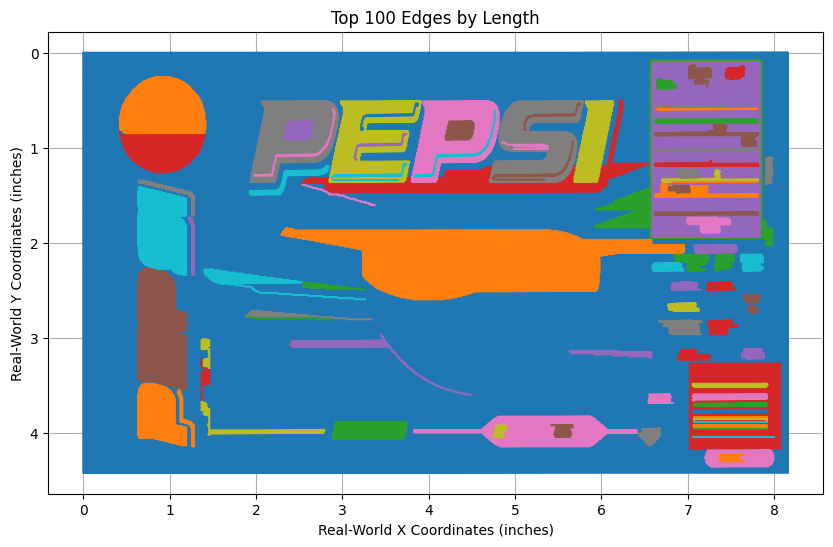

In [8]:
import matplotlib.pyplot as plt

# Process the image and get edge data
edge_data = process_image(single_image_path, output_folder, real_distance)

# Sort edges by length in descending order
sorted_edges = sorted(edge_data, key=lambda e: e["length"], reverse=True)

# Number of edges to plot
x = 100  # Replace with the desired number of edges to plot

# Plot the first x edges
plt.figure(figsize=(10, 6))
for i, edge in enumerate(sorted_edges[:x]):
    plt.plot(edge["x_coords"], edge["y_coords"], label=f"Edge {i+1} (Length: {edge['length']:.2f} inches)")

plt.title(f"Top {x} Edges by Length")
plt.xlabel("Real-World X Coordinates (inches)")
plt.ylabel("Real-World Y Coordinates (inches)")
plt.gca().invert_yaxis()  # Invert the y-axis to match the image coordinate system
#plt.legend()
plt.grid()
plt.show()

In [11]:
def segment_image_into_connected_color_clusters(image_path, color_threshold, output_folder, min_cluster_size=100):
    """
    Segments an image into clusters of connected pixels with similar colors.

    Args:
        image_path (str): Path to the input image.
        color_threshold (float): Threshold for color similarity (lower = stricter).
        output_folder (str): Path to save the segmented output images.
        min_cluster_size (int): Minimum number of pixels for a cluster to be saved.

    Returns:
        np.ndarray: The segmented image with outlined clusters.
    """
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return

    # Convert the image to LAB color space (better for color similarity)
    image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Create a blank canvas for the segmented image
    segmented_image = np.zeros_like(image)

    # Create a mask to track visited pixels
    visited = np.zeros(image_lab.shape[:2], dtype=bool)

    # Create an output folder
    os.makedirs(output_folder, exist_ok=True)

    # Cluster counter
    cluster_id = 0

    # Prepare for plotting
    fig, axes = plt.subplots(3, 5, figsize=(20, 15))  # Plot up to 15 clusters
    axes = axes.flatten()  # Flatten the 2D array into a 1D array
    plotted_clusters = 0

    # Iterate over each pixel in the image
    for y in range(image_lab.shape[0]):
        for x in range(image_lab.shape[1]):
            if visited[y, x]:
                continue

            # Start a new cluster
            cluster_mask = np.zeros(image_lab.shape[:2], dtype=bool)
            cluster_color = image_lab[y, x]

            # Perform region growing to find connected pixels with similar colors
            stack = [(y, x)]
            while stack:
                cy, cx = stack.pop()
                if visited[cy, cx]:
                    continue

                visited[cy, cx] = True
                cluster_mask[cy, cx] = True

                # Check neighbors
                for ny, nx in [(cy - 1, cx), (cy + 1, cx), (cy, cx - 1), (cy, cx + 1)]:
                    if 0 <= ny < image_lab.shape[0] and 0 <= nx < image_lab.shape[1]:
                        if not visited[ny, nx]:
                            neighbor_color = image_lab[ny, nx]
                            color_distance = np.linalg.norm(cluster_color - neighbor_color)
                            if color_distance < color_threshold:
                                stack.append((ny, nx))

            # Check if the cluster meets the minimum size requirement
            cluster_size = np.sum(cluster_mask)
            if cluster_size < min_cluster_size:
                continue  # Skip small clusters

            # Assign a random color to the cluster
            random_color = np.random.randint(0, 255, size=3, dtype=np.uint8)
            segmented_image[cluster_mask] = random_color

            # Save the cluster as an individual image
            cluster_image = np.zeros_like(image)
            cluster_image[cluster_mask] = image[cluster_mask]
            cluster_path = os.path.join(output_folder, f"cluster_{cluster_id + 1}.jpg")
            cv2.imwrite(cluster_path, cluster_image)
            print(f"Cluster {cluster_id + 1} saved to: {cluster_path}")

            # Plot the cluster (up to 15 clusters)
            if plotted_clusters < len(axes):
                axes[plotted_clusters].imshow(cv2.cvtColor(cluster_image, cv2.COLOR_BGR2RGB))
                axes[plotted_clusters].set_title(f"Cluster {cluster_id + 1}")
                axes[plotted_clusters].axis("off")
                plotted_clusters += 1

            cluster_id += 1

    # Save the final segmented image
    segmented_image_path = os.path.join(output_folder, "segmented_image.jpg")
    cv2.imwrite(segmented_image_path, segmented_image)
    print(f"Segmented image saved to: {segmented_image_path}")

    # Show the plot
    plt.tight_layout()
    plt.show()

    return segmented_image

Cluster 1 saved to: output-images-colors\cluster_1.jpg
Cluster 2 saved to: output-images-colors\cluster_2.jpg
Cluster 3 saved to: output-images-colors\cluster_3.jpg
Cluster 4 saved to: output-images-colors\cluster_4.jpg
Cluster 5 saved to: output-images-colors\cluster_5.jpg
Cluster 6 saved to: output-images-colors\cluster_6.jpg
Cluster 7 saved to: output-images-colors\cluster_7.jpg
Cluster 8 saved to: output-images-colors\cluster_8.jpg
Cluster 9 saved to: output-images-colors\cluster_9.jpg
Cluster 10 saved to: output-images-colors\cluster_10.jpg
Cluster 11 saved to: output-images-colors\cluster_11.jpg
Cluster 12 saved to: output-images-colors\cluster_12.jpg
Cluster 13 saved to: output-images-colors\cluster_13.jpg
Cluster 14 saved to: output-images-colors\cluster_14.jpg
Cluster 15 saved to: output-images-colors\cluster_15.jpg
Cluster 16 saved to: output-images-colors\cluster_16.jpg
Cluster 17 saved to: output-images-colors\cluster_17.jpg
Cluster 18 saved to: output-images-colors\cluster

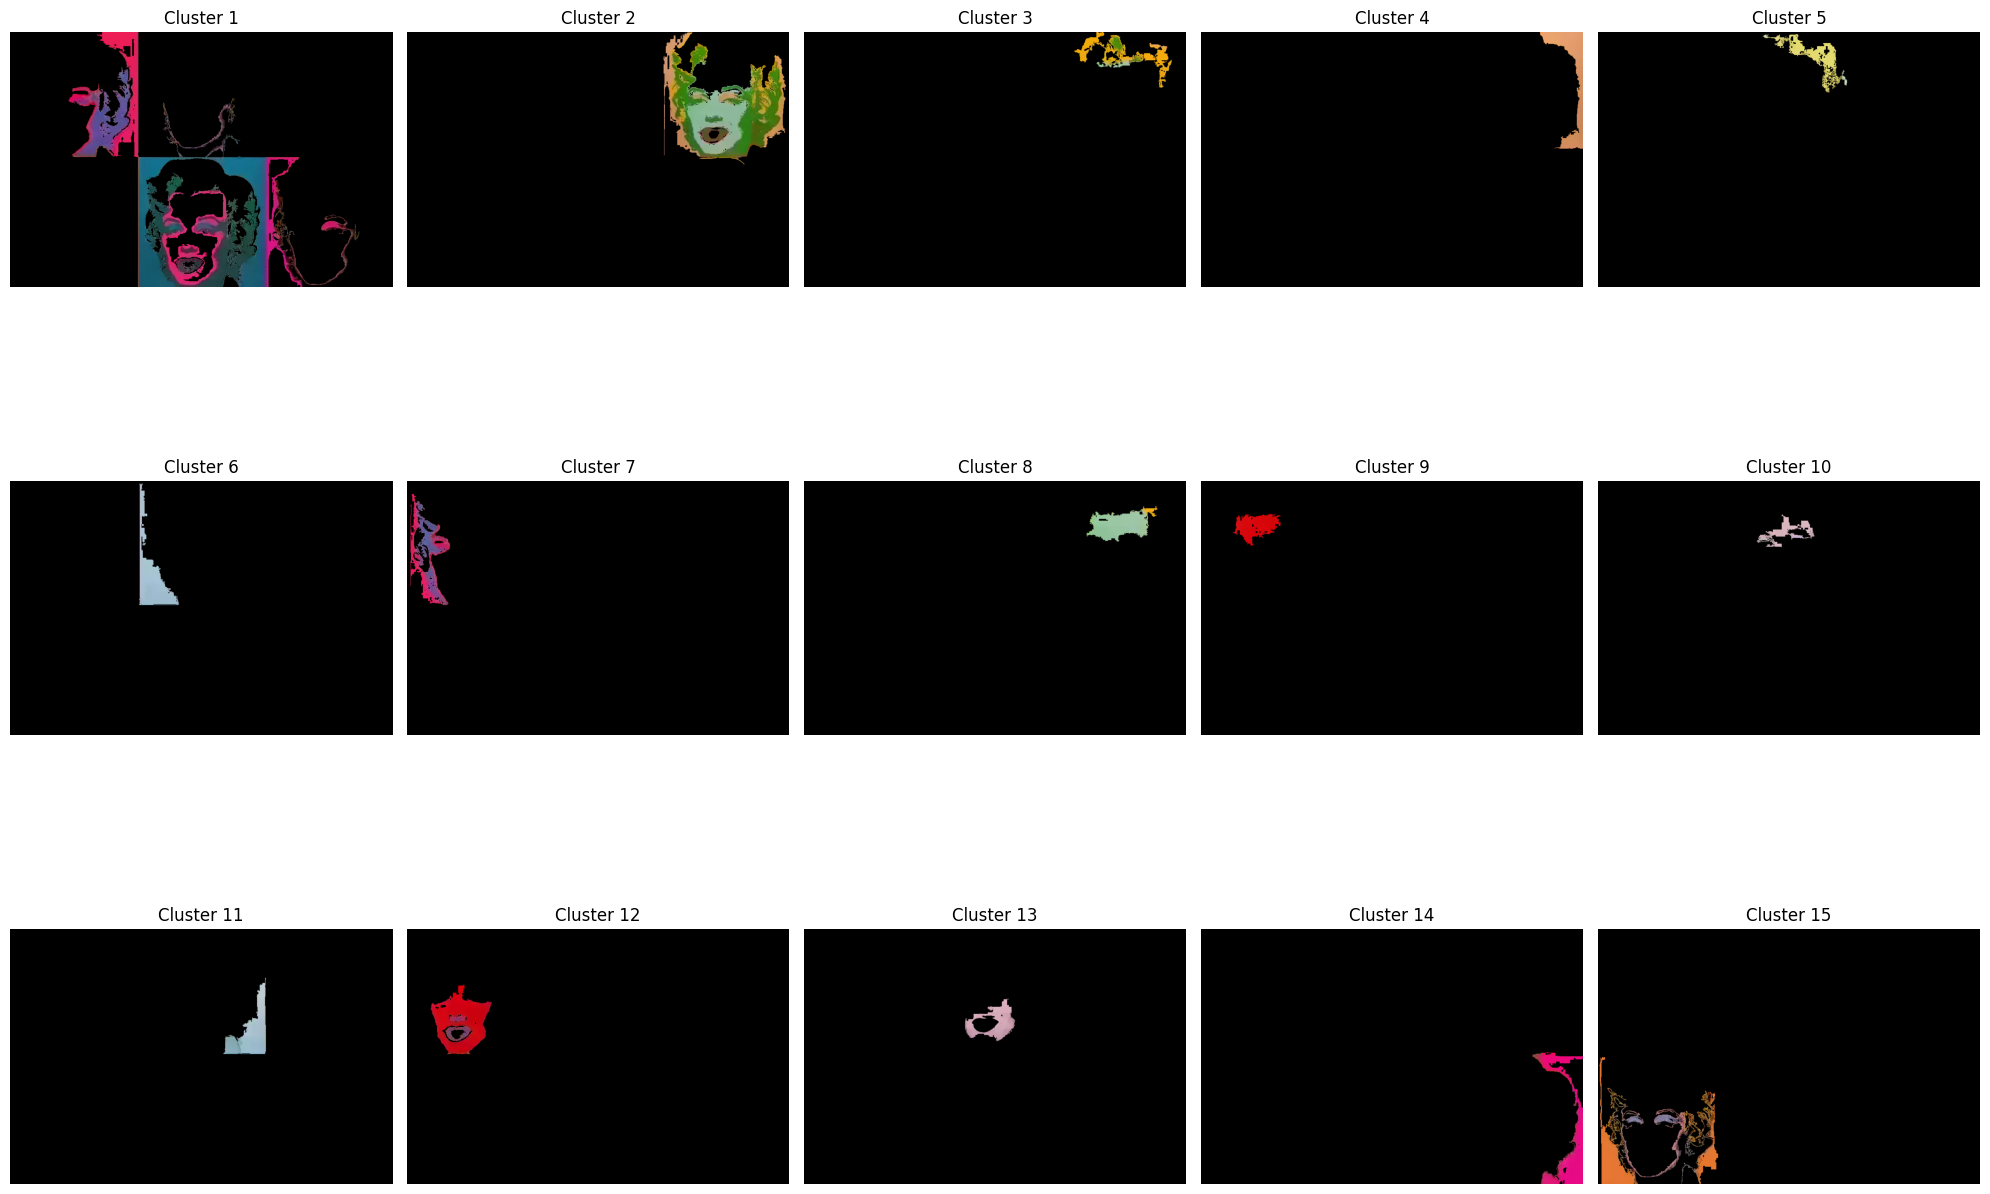

In [ ]:
# Example usage
image_path = "test-images/mm.png"  # Replace with your image path
output_folder = "output-images-colors"  # Replace with your output folder path
color_threshold = 30.0  # Adjust for stricter or looser color similarity
min_cluster_size = 2000  # Minimum size of clusters to save

segmented_image = segment_image_into_connected_color_clusters(image_path, color_threshold, output_folder, min_cluster_size)